# Predictive Modeling: LSTM (Keras)

Loads the engineered features from Turso, filters to a single coin (BTC), and trains an LSTM to predict the next day's closing price from the last 60 days of OHLCV + a couple of indicators.

Two things earlier attempts at this got wrong, that this notebook fixes:
- **Train/test split is time-based, not random.** This is a time series - a random split lets the model "see" days that come after the days it's tested on, which quietly inflates performance.
- **Scaling is fit on the training period only**, then applied to the test period. Fitting the scaler on the full series (including test) leaks the test period's min/max into training.

This notebook models one coin at a time (BTC first). The reason: this dataset stacks ~15 coins with wildly different price scales (BTC in the tens of thousands, some coins under $1) into one table, and a single shared model/scaler across all of them either drowns the small coins out or needs a lot more care (per-coin scaling, an explicit coin embedding, etc.) than is worth taking on before a single-coin model is known to work. The same cells below work for any other `Symbol` in the table - just change `COIN`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers

from db import load_df

In [2]:
COIN = 'BTC'

df = load_df('engineered_features')
df['Date'] = pd.to_datetime(df['Date'])

coin_df = df[df['Symbol'] == COIN].sort_values('Date').reset_index(drop=True)
print(f"{COIN}: {len(coin_df)} rows, {coin_df['Date'].min().date()} to {coin_df['Date'].max().date()}")
coin_df.head()

BTC: 4292 rows, 2014-12-15 to 2026-09-14


C:\Users\ethan\Documents\DataScience\Crypto-Optimization\Crypto-Portfolio-Optimization-and-Risk-Analysis\db.py:90: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {table_name}", conn)


,Date,Adj Close,Close,High,Low,Open,Volume($),Symbol,Daily Return,SMA_30,...,Close_rolling_std_7,Volume_rolling_mean_7,Volume_rolling_std_7,Close_rolling_mean_30,Close_rolling_std_30,Volume_rolling_mean_30,Volume_rolling_std_30,Year,Month,Day
0,2014-12-15,345.345001,345.345001,351.815002,344.933990,351.360992,17264200,BTC,-0.017879,367.343332,...,2.993600,2.001709e+07,8.920691e+06,367.343332,13.122712,1.870077e+07,8.860558e+06,2014,12,15
1,2014-12-16,327.062012,327.062012,345.859009,327.062012,345.673004,30864900,BTC,-0.052941,365.315999,...,8.715197,1.972414e+07,8.447659e+06,365.315999,14.469239,1.933274e+07,9.033625e+06,2014,12,16
2,2014-12-17,319.776001,319.776001,333.954010,315.152008,326.855011,37567900,BTC,-0.022277,363.061600,...,13.123725,2.274417e+07,1.058196e+07,363.061600,16.086805,1.920105e+07,8.722473e+06,2014,12,17
3,2014-12-18,311.395996,311.395996,323.709015,304.231995,319.785004,39173000,BTC,-0.026206,360.934866,...,16.742179,2.370727e+07,1.184230e+07,360.934866,18.468170,1.943273e+07,9.161529e+06,2014,12,18
4,2014-12-19,317.842987,317.842987,318.532990,306.769012,311.178986,23823100,BTC,0.020704,358.844466,...,16.313904,2.468346e+07,1.147213e+07,358.844466,19.680196,1.959577e+07,9.195767e+06,2014,12,19


### Sequences: time-based split, scale using train-only stats

`Close` is the target and is also one of the input features (an LSTM predicting tomorrow's price from a window that includes today's price is normal - it's not the same leak as, say, including tomorrow's price as an input). Lag/rolling-of-`Close` columns (`Close_lag_1`, `Close_rolling_mean_7`, ...) are deliberately left out of the feature list - they're near-copies of the target, so including them would let the model "cheat" by copying a lag instead of learning the sequence, and would make it hard to tell how much of any accuracy is real.

In [3]:
FEATURES = ['Close', 'Open', 'High', 'Low', 'Volume($)', 'RSI', 'MACD']
TARGET_IDX = FEATURES.index('Close')
WINDOW = 60          # days of history the model sees per prediction
TEST_FRACTION = 0.15  # last 15% of days, by time, held out

data = coin_df[FEATURES].values
n_test = int(len(data) * TEST_FRACTION)
split = len(data) - n_test

# Fit scalers on the training period ONLY, then apply to the whole series.
feature_scaler = MinMaxScaler()
feature_scaler.fit(data[:split])

# Separate scaler for Close alone, so predictions can be inverse-transformed
# back to dollars without needing to fake the other 6 feature columns.
close_scaler = MinMaxScaler()
close_scaler.fit(data[:split, [TARGET_IDX]])

scaled = feature_scaler.transform(data)
print(f"train rows: {split}, test rows: {n_test}")

train rows: 3649, test rows: 643


In [4]:
def make_sequences(arr, start, end, window, target_idx):
    """Build (X, y) windows for indices [start, end). Each y is arr[i, target_idx];
    each X is the `window` rows immediately before it - so the test sequences
    are allowed to look back into the tail of the training period (that's just
    history, not test-period information leaking into training)."""
    xs, ys = [], []
    for i in range(start, end):
        xs.append(arr[i - window:i])
        ys.append(arr[i, target_idx])
    return np.array(xs), np.array(ys)


X_train, y_train = make_sequences(scaled, WINDOW, split, WINDOW, TARGET_IDX)
X_test, y_test = make_sequences(scaled, split, len(scaled), WINDOW, TARGET_IDX)
print(f"X_train {X_train.shape}, X_test {X_test.shape}")

X_train (3589, 60, 7), X_test (643, 60, 7)


### Model

In [5]:
model = keras.Sequential([
    layers.Input(shape=(WINDOW, len(FEATURES))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(1),
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
)

final_loss = history.history['loss'][-1]
assert np.isfinite(final_loss), f"Training loss is not finite ({final_loss}) - check the scaling/inputs above."
print(f"final train loss: {final_loss:.6f}")

Epoch 1/50


  1/101 ━━━━━━━━━━━━━━━━━━━━ 3:31 2s/step - loss: 0.0308

  4/101 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0193

  7/101 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0130

 10/101 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0107

...

 95/101 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.2029e-04

 98/101 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.2455e-04

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.2411e-04

101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 3.2411e-04 - val_loss: 0.0012


final train loss: 0.000324

### Evaluate

Reporting whatever these numbers come out to be - no cherry-picking a better epoch or run.

In [7]:
pred_scaled = model.predict(X_test).reshape(-1, 1)
predicted = close_scaler.inverse_transform(pred_scaled).flatten()
actual = close_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"{COIN} test set ({len(actual)} days):")
print(f"  MAE:  {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  MAPE: {mape:.2f}%")

 1/21 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step

 7/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  

12/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

18/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


BTC test set (643 days):
  MAE:  3,536.73
  RMSE: 4,552.05
  MAPE: 3.68%


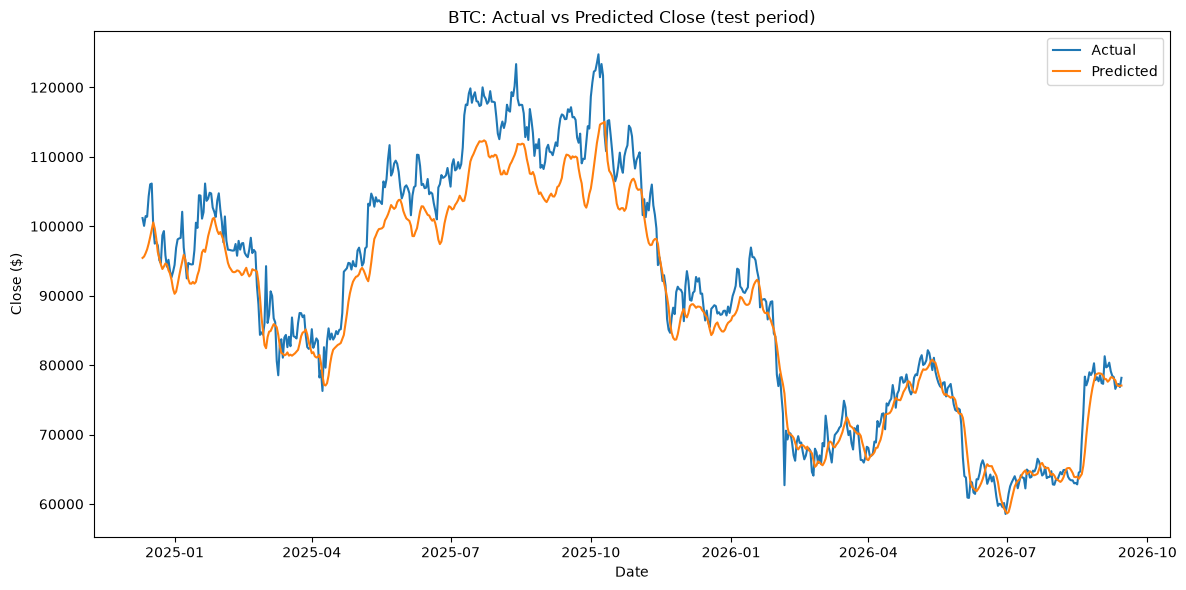

In [8]:
test_dates = coin_df['Date'].values[split:]

plt.figure(figsize=(12, 6))
plt.plot(test_dates, actual, label='Actual', color='tab:blue')
plt.plot(test_dates, predicted, label='Predicted', color='tab:orange')
plt.title(f'{COIN}: Actual vs Predicted Close (test period)')
plt.xlabel('Date')
plt.ylabel('Close ($)')
plt.legend()
plt.tight_layout()
plt.show()